### Обработка набора данных

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

Считывание данных с помощью keras.datasets.fashion_mnist.load_data

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

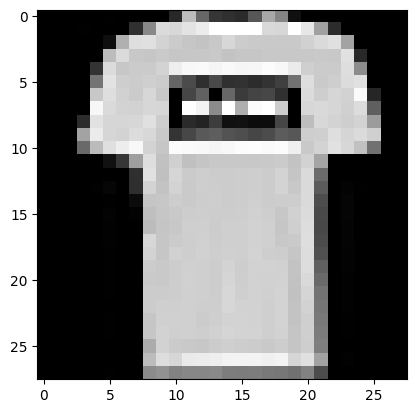

In [5]:
plt.imshow(x_train[1], cmap="gray")

Нормализация

In [6]:
x_train = x_train / 255
x_test = x_test / 255

Преобразование картинок в "линию"

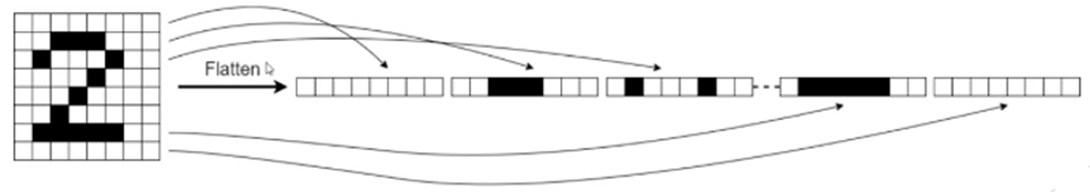

In [7]:
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1] * x_train.shape[2])
x_train.shape

(60000, 784)

In [8]:
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1] * x_test.shape[2])
x_test.shape

(10000, 784)

In [9]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

Преобразование классов в one-hot енкодинг с помощью keras.utils.to_categorical

In [10]:
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_train

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [11]:
y_train.shape

(60000, 10)

In [12]:
y_test = keras.utils.to_categorical(y_test, num_classes)
y_test

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [13]:
x_test[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [14]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

Создание "последовательной" модели

In [15]:
input_shape = (x_train[0].shape)
input_shape

(784,)

In [18]:
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Dense(100, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [19]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 100)               78500     
                                                                 
 dense_3 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [20]:
model.compile(loss="categorical_crossentropy", optimizer="adam", 
              metrics=["accuracy"])

In [21]:
y_train

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [22]:
batch_size = 128
epochs = 20
history = model.fit(x_train, y_train, batch_size=batch_size, 
                    epochs=epochs, validation_split=0.1)

Epoch 1/20
422/422 [==============================] - 2s 3ms/step - loss: 0.5828 - accuracy: 0.8016 - val_loss: 0.4659 - val_accuracy: 0.8342
Epoch 2/20
422/422 [==============================] - 1s 3ms/step - loss: 0.4202 - accuracy: 0.8530 - val_loss: 0.3928 - val_accuracy: 0.8602
Epoch 3/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3826 - accuracy: 0.8662 - val_loss: 0.3858 - val_accuracy: 0.8622
Epoch 4/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3562 - accuracy: 0.8736 - val_loss: 0.3558 - val_accuracy: 0.8733
Epoch 5/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3360 - accuracy: 0.8809 - val_loss: 0.3510 - val_accuracy: 0.8762
Epoch 6/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3185 - accuracy: 0.8855 - val_loss: 0.3459 - val_accuracy: 0.8745
Epoch 7/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3091 - accuracy: 0.8891 - val_loss: 0.3393 - val_accuracy: 0.8783
Epoch 

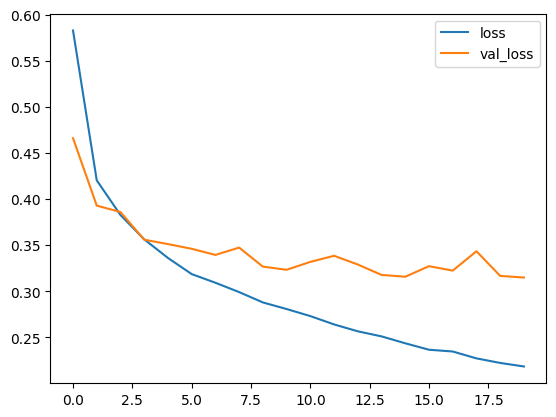

In [23]:
plt.plot(history.history['loss'], label="loss")
plt.plot(history.history['val_loss'], label="val_loss")
plt.legend()

In [24]:
history.history

{'loss': [0.5827691555023193,
  0.42018672823905945,
  0.3825635612010956,
  0.3561965525150299,
  0.3359759449958801,
  0.31849396228790283,
  0.3090915083885193,
  0.29894423484802246,
  0.2877318859100342,
  0.28057512640953064,
  0.2729180157184601,
  0.2638951241970062,
  0.256401002407074,
  0.25091439485549927,
  0.24340851604938507,
  0.23642276227474213,
  0.2345043420791626,
  0.2270386964082718,
  0.22209586203098297,
  0.2182570844888687],
 'accuracy': [0.8016481399536133,
  0.8530185222625732,
  0.8662222027778625,
  0.8736110925674438,
  0.880907416343689,
  0.8855000138282776,
  0.8890740871429443,
  0.891703724861145,
  0.8974259495735168,
  0.899648129940033,
  0.9000185132026672,
  0.9048333168029785,
  0.9067592620849609,
  0.9092037081718445,
  0.9104074239730835,
  0.9149629473686218,
  0.9149629473686218,
  0.9171110987663269,
  0.9195185303688049,
  0.9202592372894287],
 'val_loss': [0.4659454822540283,
  0.39277738332748413,
  0.3858257234096527,
  0.35579100251

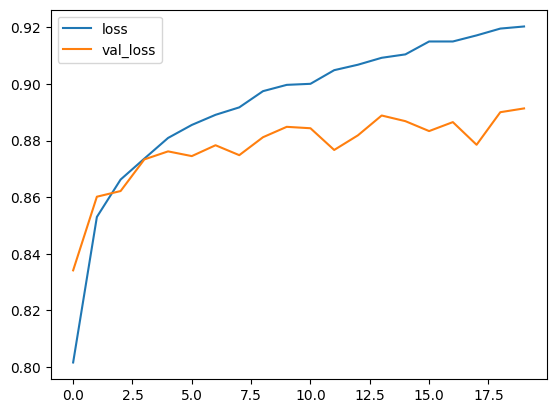

In [25]:
plt.plot(history.history['accuracy'], label="loss")
plt.plot(history.history['val_accuracy'], label="val_loss")
plt.legend()

In [26]:
history = model.fit(x_train, y_train, batch_size=batch_size, 
                    epochs=10, validation_split=0.1)

Epoch 1/10
422/422 [==============================] - 1s 3ms/step - loss: 0.2137 - accuracy: 0.9226 - val_loss: 0.3229 - val_accuracy: 0.8887
Epoch 2/10
422/422 [==============================] - 1s 3ms/step - loss: 0.2106 - accuracy: 0.9221 - val_loss: 0.3388 - val_accuracy: 0.8818
Epoch 3/10
422/422 [==============================] - 1s 3ms/step - loss: 0.2055 - accuracy: 0.9253 - val_loss: 0.3161 - val_accuracy: 0.8905
Epoch 4/10
422/422 [==============================] - 1s 3ms/step - loss: 0.2016 - accuracy: 0.9263 - val_loss: 0.3409 - val_accuracy: 0.8890
Epoch 5/10
422/422 [==============================] - 1s 3ms/step - loss: 0.1993 - accuracy: 0.9279 - val_loss: 0.3289 - val_accuracy: 0.8887
Epoch 6/10
422/422 [==============================] - 1s 3ms/step - loss: 0.1951 - accuracy: 0.9297 - val_loss: 0.3276 - val_accuracy: 0.8892
Epoch 7/10
422/422 [==============================] - 1s 3ms/step - loss: 0.1900 - accuracy: 0.9309 - val_loss: 0.3347 - val_accuracy: 0.8893
Epoch 

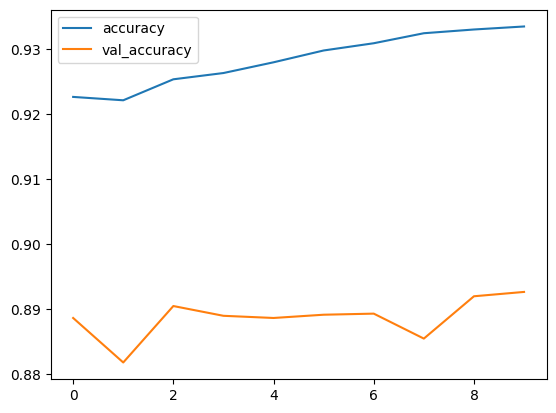

In [27]:
plt.plot(history.history['accuracy'], label="accuracy")
plt.plot(history.history['val_accuracy'], label="val_accuracy")
plt.legend()

In [28]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.3459 - accuracy: 0.8881


[0.345867395401001, 0.8881000280380249]

In [29]:
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Dense(100, activation="relu"),
    layers.Dense(100, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
batch_size = 128
epochs = 20
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/20
422/422 [==============================] - 2s 3ms/step - loss: 0.5683 - accuracy: 0.8009 - val_loss: 0.4292 - val_accuracy: 0.8450
Epoch 2/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3972 - accuracy: 0.8594 - val_loss: 0.3743 - val_accuracy: 0.8652
Epoch 3/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3573 - accuracy: 0.8712 - val_loss: 0.3584 - val_accuracy: 0.8675
Epoch 4/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3316 - accuracy: 0.8792 - val_loss: 0.3354 - val_accuracy: 0.8790
Epoch 5/20
422/422 [==============================] - 1s 3ms/step - loss: 0.3123 - accuracy: 0.8865 - val_loss: 0.3322 - val_accuracy: 0.8783
Epoch 6/20
422/422 [==============================] - 1s 3ms/step - loss: 0.2935 - accuracy: 0.8929 - val_loss: 0.3725 - val_accuracy: 0.8642
Epoch 7/20
422/422 [==============================] - 1s 3ms/step - loss: 0.2860 - accuracy: 0.8942 - val_loss: 0.3284 - val_accuracy: 0.8802
Epoch 

In [30]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.3559 - accuracy: 0.8839


[0.355930894613266, 0.883899986743927]